Primer EDA sobre el data set AIR BNB 2019 NY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

abnb_orig = pd.read_csv('data/raw/AB_NYC_2019.csv')
print(type(abnb_orig))


<class 'pandas.core.frame.DataFrame'>


Primer analisis de los datos del Data Set de AIR BNB 2019

In [3]:
abnb_orig.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [4]:
abnb_orig.shape

(48895, 16)

In [5]:
abnb_orig.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
abnb_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [7]:
abnb_orig.dtypes.value_counts()

int64      7
object     6
float64    3
Name: count, dtype: int64

In [10]:
abnb_orig.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Imputando los valores nulos identificados 

In [ ]:

abnb_orig['reviews_per_month'] = abnb_orig['reviews_per_month'].fillna(0)
abnb_orig['name'] = abnb_orig['name'].fillna("Sin Nombre")
abnb_orig['host_name'] = abnb_orig['host_name'].fillna("Desconocido")

Definicion de variables para el estudio 

In [11]:
var_texto = abnb_orig.select_dtypes(include=(['object'])).columns.tolist() # Posibles variables categoricas
var_numericas = abnb_orig.select_dtypes(include=['int64','float64']).columns.tolist()
print("Variables Texto")
print(var_texto)
print("\nVariables Numéricas")
print(var_numericas) 

Variables Texto
['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']

Variables Numéricas
['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


Las variables que incluyen revisión como "last_review" y "review_per_month" tienen 10052 datos faltantes lo que me hace pensar que la variable "number_of_reviews" que cuenta las revisiones debe tener el mismo número de ceros 

In [12]:
cant_ceros_numbrev = (abnb_orig['number_of_reviews']==0).sum()
print(cant_ceros_numbrev)

10052


Una variable que puede ser útil para extraer algo de informacion sobre este Data Set es "Neighboorhood_gorup", considerando que puede ser categórica naturalmente 

In [13]:
abnb_orig['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

La variable de precios es una variable numérica importante para definir si los registros son útiles o no.   

In [14]:
cant_ceros_price = (abnb_orig['price']== 0).sum()
cant_ceros_price

np.int64(11)

La politca de AIR BNB como aplicación no permite guardar anuncios con precios cero. Sin embargo, dentro de nuestro registros hay once registros de precio cero, si bien es el 0.02% de los datos puede deberse al origen del Data Set. No descartaremos esta variable por ese mínimo registro erróneo.

Revisando estos registros de precio cero encontramos 

In [15]:
colum_show = ['price', 'name', 'neighbourhood', 'neighbourhood_group', 'room_type']
tab_precios_cero = abnb_orig[abnb_orig['price'] == 0][colum_show]
tab_precios_cero

,price,name,neighbourhood,neighbourhood_group,room_type
23161,0,"Huge Brooklyn Brownstone Living, Close to it all.",Bedford-Stuyvesant,Brooklyn,Private room
25433,0,★Hostel Style Room | Ideal Traveling Buddies★,East Morrisania,Bronx,Private room
25634,0,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",Bushwick,Brooklyn,Private room
25753,0,"Sunny, Quiet Room in Greenpoint",Greenpoint,Brooklyn,Private room
25778,0,Modern apartment in the heart of Williamsburg,Williamsburg,Brooklyn,Entire home/apt
25794,0,Spacious comfortable master bedroom with nice ...,Bedford-Stuyvesant,Brooklyn,Private room
25795,0,Contemporary bedroom in brownstone with nice view,Bedford-Stuyvesant,Brooklyn,Private room
25796,0,Cozy yet spacious private brownstone bedroom,Bedford-Stuyvesant,Brooklyn,Private room
26259,0,the best you can find,Murray Hill,Manhattan,Entire home/apt
26841,0,Coliving in Brooklyn! Modern design / Shared room,Bushwick,Brooklyn,Shared room


Intento revisar si esos precios cero se refieren a registros duplicados o que puedan ensuciar en algo los valores estadísticos 

In [16]:
# Revisamos si hay filas COMPLETAMENTE idénticas en esta subtabla
duplicados_exactos = tab_precios_cero.duplicated().sum()
print(f"Hay {duplicados_exactos} filas 100% idénticas en la tabla de precios cero.")

# Revisamos si hay anuncios repetidos (por nombre, anfitrión y barrio) en esta subtabla
duplicados_parciales = tab_precios_cero.duplicated(subset=['name','price', 'neighbourhood']).sum()
#print(f"Hay {duplicados_parciales} anuncios repetidos (por nombre, host y barrio

Hay 0 filas 100% idénticas en la tabla de precios cero.


In [17]:

tabla_precios_cero = abnb_orig[abnb_orig['price'] == 0]

# Definimos las columnas que identifican a un anuncio único
columnas_clave = ['name', 'host_id', 'neighbourhood']

# Buscamos esos anuncios en la tabla COMPLETA
# Usamos "how='inner'" para decirle: "muéstrame solo lo que exista en ambas tablas a la vez"
registros_comunes = abnb_orig.merge(tabla_precios_cero[columnas_clave].drop_duplicates(),on=columnas_clave, how='inner')

# Resultados: Queremos saber si alguno de esos anuncios tiene un precio normal (mayor a 0)
print(f"Total de registros de esos alojamientos en toda la tabla: {len(registros_comunes)}")
print(f"De esos, ¿cuántos están registrados con un precio mayor a 0?: {len(registros_comunes[registros_comunes['price'] > 0])}")

# Mostramos el resultado limpio
registros_comunes[['name', 'host_id', 'neighbourhood', 'price']]

Total de registros de esos alojamientos en toda la tabla: 11
De esos, ¿cuántos están registrados con un precio mayor a 0?: 0


,name,host_id,neighbourhood,price
0,"Huge Brooklyn Brownstone Living, Close to it all.",8993084,Bedford-Stuyvesant,0
1,★Hostel Style Room | Ideal Traveling Buddies★,131697576,East Morrisania,0
2,"MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)",15787004,Bushwick,0
3,"Sunny, Quiet Room in Greenpoint",1641537,Greenpoint,0
4,Modern apartment in the heart of Williamsburg,10132166,Williamsburg,0
5,Spacious comfortable master bedroom with nice ...,86327101,Bedford-Stuyvesant,0
6,Contemporary bedroom in brownstone with nice view,86327101,Bedford-Stuyvesant,0
7,Cozy yet spacious private brownstone bedroom,86327101,Bedford-Stuyvesant,0
8,the best you can find,13709292,Murray Hill,0
9,Coliving in Brooklyn! Modern design / Shared room,101970559,Bushwick,0


In [18]:
print("\n--- ESTADÍSTICAS DE PRECIO ---")
print(abnb_orig['price'].describe())


--- ESTADÍSTICAS DE PRECIO ---
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


Estadística general de algunas de las variables numéricas importantes 

In [19]:
print("--- ESTADÍSTICAS DE VARIABLES NUMÉRICAS ---")
num_vars = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
print(abnb_orig[num_vars].describe())

--- ESTADÍSTICAS DE VARIABLES NUMÉRICAS ---
       minimum_nights  number_of_reviews  reviews_per_month  availability_365
count    48895.000000       48895.000000       38843.000000      48895.000000
mean         7.029962          23.274466           1.373221        112.781327
std         20.510550          44.550582           1.680442        131.622289
min          1.000000           0.000000           0.010000          0.000000
25%          1.000000           1.000000           0.190000          0.000000
50%          3.000000           5.000000           0.720000         45.000000
75%          5.000000          24.000000           2.020000        227.000000
max       1250.000000         629.000000          58.500000        365.000000


Top 10 barrios (Neighbourhoods) con mas anuncios 

In [20]:
print("\n--- TOP 10 BARRIOS (NEIGHBOURHOODS) CON MÁS ANUNCIOS ---")
# Usamos value_counts() para contar frecuencias y head(10) para los primeros
print(abnb_orig['neighbourhood'].value_counts().head(10))


--- TOP 10 BARRIOS (NEIGHBOURHOODS) CON MÁS ANUNCIOS ---
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


Estadística de la variable 

In [21]:
abnb_orig.groupby('neighbourhood_group')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1091.0,87.496792,106.709349,0.0,45.0,65.0,99.0,2500.0
Brooklyn,20104.0,124.383207,186.873538,0.0,60.0,90.0,150.0,10000.0
Manhattan,21661.0,196.875814,291.383183,0.0,95.0,150.0,220.0,10000.0
Queens,5666.0,99.517649,167.102155,10.0,50.0,75.0,110.0,10000.0
Staten Island,373.0,114.812332,277.620403,13.0,50.0,75.0,110.0,5000.0


Anuncios con mínimo de noches extremos (> 365 dias)

In [22]:
print("\n--- ANUNCIOS CON MÍNIMO DE NOCHES EXTREMOS (> 365) ---")
extreme_nights = abnb_orig[abnb_orig['minimum_nights'] > 365]
print(f"Cantidad de anuncios que exigen más de un año: {len(extreme_nights)}")

# Mostrar una pequeña muestra para ver de qué tipo son
if len(extreme_nights) > 0:
    print("\nMuestra de estos anuncios:")
    print(extreme_nights[['neighbourhood_group', 'room_type', 'minimum_nights']].head())


--- ANUNCIOS CON MÍNIMO DE NOCHES EXTREMOS (> 365) ---
Cantidad de anuncios que exigen más de un año: 14

Muestra de estos anuncios:
     neighbourhood_group        room_type  minimum_nights
1305            Brooklyn  Entire home/apt             370
2854           Manhattan  Entire home/apt            1000
5767           Manhattan  Entire home/apt            1250
7355              Queens  Entire home/apt             500
8014           Manhattan  Entire home/apt             500


Analsiis de disponibilidad nula 

In [23]:
print("\n--- DISPONIBILIDAD (availability_365) ---")
# Contamos cuántas filas tienen exactamente un 0 en disponibilidad
zero_avail = len(abnb_orig[abnb_orig['availability_365'] == 0])
total_anuncios = len(abnb_orig)
porcentaje_zero = (zero_avail / total_anuncios) * 100

print(f"Anuncios con 0 días de disponibilidad al año: {zero_avail}")
print(f"Esto representa el {porcentaje_zero:.2f}% de todo el mercado de NYC.")


--- DISPONIBILIDAD (availability_365) ---
Anuncios con 0 días de disponibilidad al año: 17533
Esto representa el 35.86% de todo el mercado de NYC.


Top 5 de anfitriones con mayor número de anuncios

In [24]:
print("\n--- TOP 5 ANFITRIONES CON MÁS ANUNCIOS ---")
top_hosts = abnb_orig[['host_name', 'calculated_host_listings_count']].drop_duplicates().sort_values(by='calculated_host_listings_count', ascending=False).head(5)
print(top_hosts)


--- TOP 5 ANFITRIONES CON MÁS ANUNCIOS ---
          host_name  calculated_host_listings_count
38293  Sonder (NYC)                             327
26137    Blueground                             232
9740           Kara                             121
32718        Kazuya                             103
30637        Sonder                              96


Distribución de tipos de habitación 

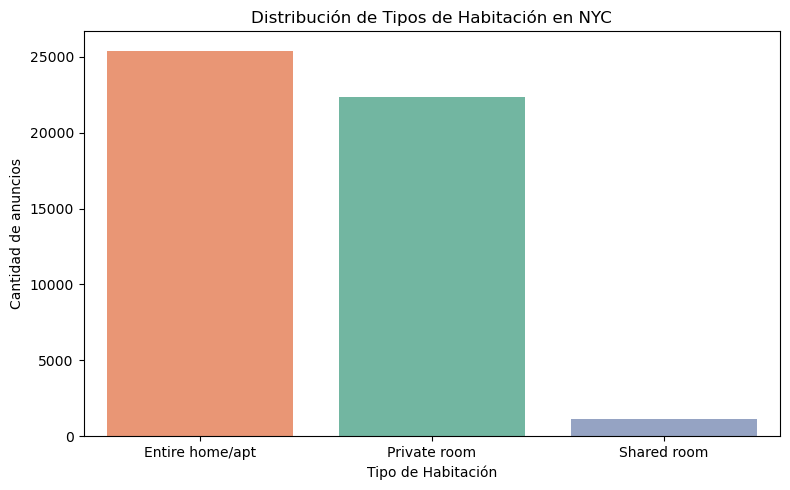

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=abnb_orig, x='room_type', hue='room_type', palette='Set2', legend=False, order=abnb_orig['room_type'].value_counts().index)
plt.title('Distribución de Tipos de Habitación en NYC')
plt.ylabel('Cantidad de anuncios')
plt.xlabel('Tipo de Habitación')
plt.tight_layout()
plt.savefig('room_type_dist.png') # Guarda la imagen
plt.show()

Distribución por distrito 

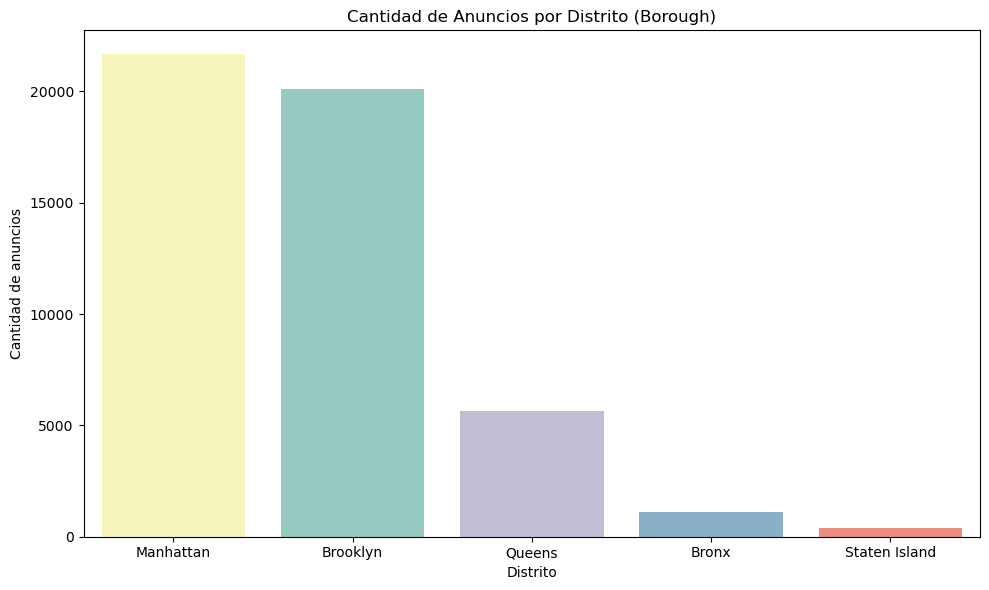

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(data=abnb_orig, x='neighbourhood_group', hue='neighbourhood_group', palette='Set3', legend=False, order=abnb_orig['neighbourhood_group'].value_counts().index)
plt.title('Cantidad de Anuncios por Distrito (Borough)')
plt.ylabel('Cantidad de anuncios')
plt.xlabel('Distrito')
plt.tight_layout()
plt.savefig('neighbourhood_dist.png')
plt.show()

Cuenta de cantidad de alojamientos por cada distrito 

<Axes: xlabel='neighbourhood_group', ylabel='count'>

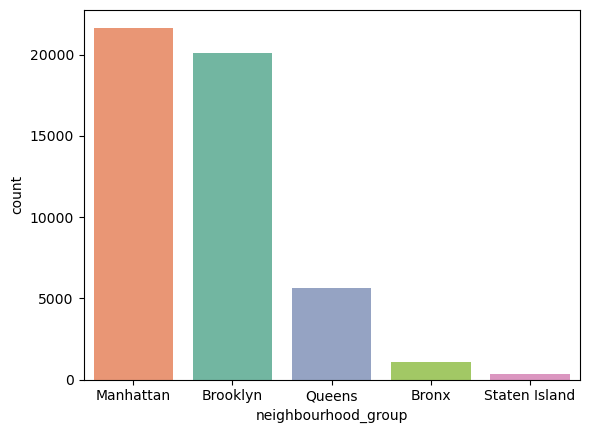

In [32]:
sns.countplot(data=abnb_orig, x='neighbourhood_group', hue='neighbourhood_group', palette='Set2', legend=False, order=abnb_orig['neighbourhood_group'].value_counts().index)

Distribución de precios (filtrando Outliers > 500) 

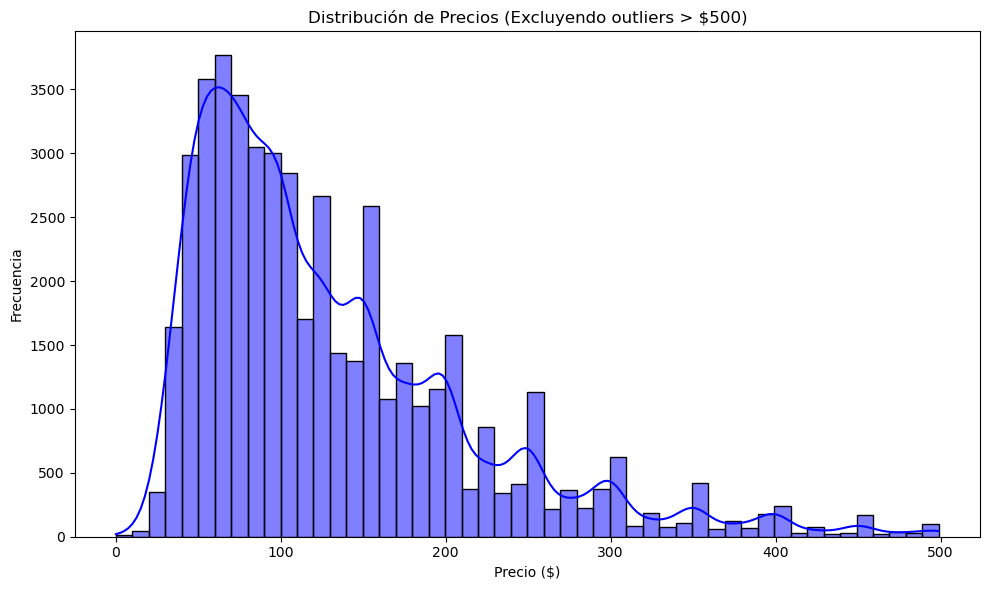

In [27]:
plt.figure(figsize=(10, 6))
# Filtramos los precios altísimos para poder ver bien la campana principal
sns.histplot(abnb_orig[abnb_orig['price'] < 500]['price'], bins=50, kde=True, color='blue')
plt.title('Distribución de Precios (Excluyendo outliers > $500)')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('price_dist.png')
plt.show()

DIstribución de precios por distrito (< 500)

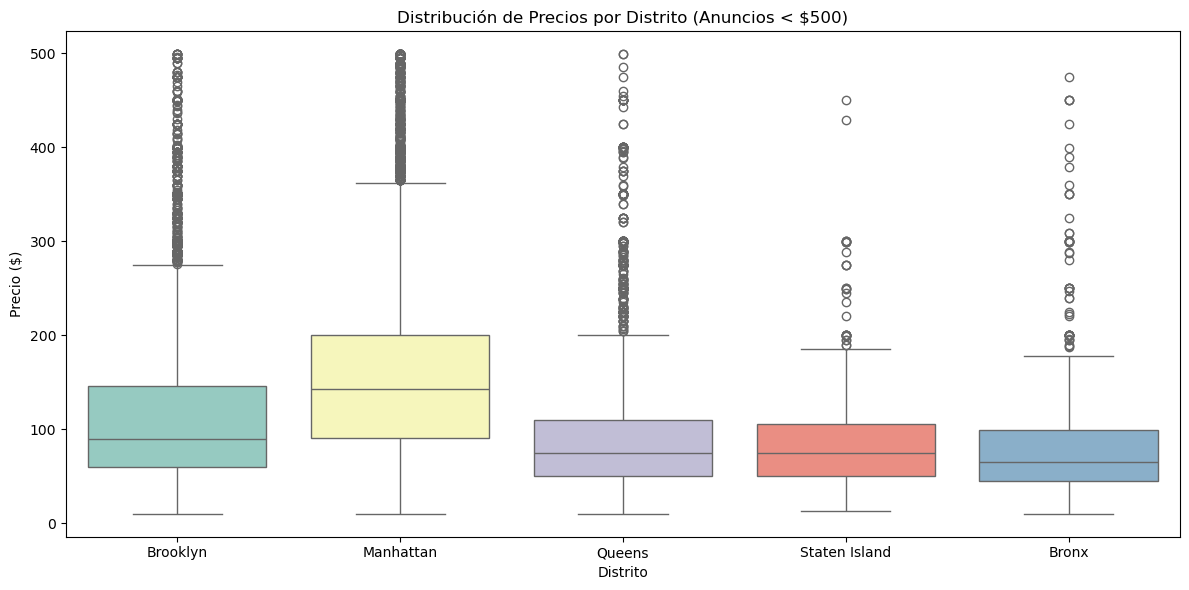

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=abnb_clean[abnb_clean['price'] < 500], x='neighbourhood_group', y='price', hue='neighbourhood_group',palette='Set3',legend=False)
plt.title('Distribución de Precios por Distrito (Anuncios < $500)')
plt.xlabel('Distrito')
plt.ylabel('Precio ($)')
plt.tight_layout()
plt.savefig('price_by_neighborhood.png')
plt.show()

En esta sección aplicaré un tratamiento de winsorización para manejar los posibles outliers. He elegido este método porque sé que los precios altos no representan un error en los datos, sino una estrategia real del mercado. Por lo tanto, realizaré este ajuste únicamente para hacer una comparación visual y matemática, demostrando así que estos valores extremos no alteran de manera significativa las estadísticas generales 

In [21]:
# 1. Eliminar precios en 0 (Trimming)
abnb_clean = abnb_orig[abnb_orig['price'] > 0].copy()

# 2. Limitar precios altísimos al percentil 99 (Winsorization)
limite_precio = abnb_clean['price'].quantile(0.99)
abnb_clean['price'] = np.where(abnb_clean['price'] > limite_precio, limite_precio, abnb_clean['price'])

# 3. Limitar noches mínimas a un máximo de 365 días (Winsorization)
abnb_clean['minimum_nights'] = np.where(abnb_clean['minimum_nights'] > 365, 365, abnb_clean['minimum_nights'])

print(f"Dimensión original: {abnb_orig.shape}")
print(f"Dimensión limpia: {abnb_clean.shape}")

Dimensión original: (48895, 16)
Dimensión limpia: (48884, 16)


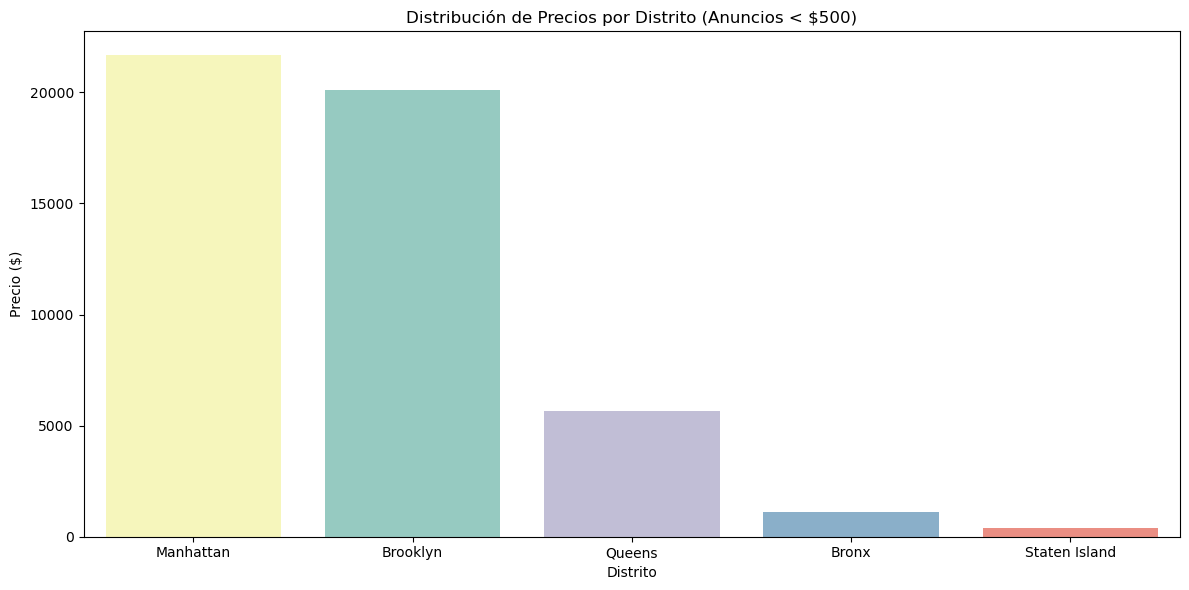

In [26]:
plt.figure(figsize=(12, 6))
sns.countplot(data=abnb_orig, x='neighbourhood_group', hue='neighbourhood_group', palette='Set3', legend=False, order=abnb_orig['neighbourhood_group'].value_counts().index)
plt.title('Distribución de Precios por Distrito (Anuncios < $500)')
plt.xlabel('Distrito')
plt.ylabel('Precio ($)')
plt.tight_layout()
plt.savefig('price_by_neighborhood.png')
plt.show()

In [ ]:

# ESTADÍSTICAS ANTES (Data Original)

print("ESTADÍSTICAS ANTES DE LIMPIAR")
# .describe() por defecto trae la media (mean)
# Agregamos percentiles específicos. El 50% es tu mediana.
stats_antes = abnb_orig['price'].describe(percentiles=[.25, .50, .75, .90, .95, .99])
print(stats_antes)
print("\n" + "="*40 + "\n")


# 3. ESTADÍSTICAS DESPUÉS (Data Limpia)

print("ESTADÍSTICAS DESPUÉS DE WINSORIZAR")
stats_despues = abnb_clean['price'].describe(percentiles=[.25, .50, .75, .90, .95, .99])
print(stats_despues)

--- ESTADÍSTICAS ANTES DE LIMPIAR ---
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
90%        269.000000
95%        355.000000
99%        799.000000
max      10000.000000
Name: price, dtype: float64


--- ESTADÍSTICAS DESPUÉS DE WINSORIZAR ---
count    48884.000000
mean       143.988626
std        121.929660
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
90%        269.000000
95%        355.000000
99%        799.000000
max        799.000000
Name: price, dtype: float64


Este panel de gráficos ilustra el tratamiento de los outliers. Sin embargo, para este análisis también es posible extraer conclusiones válidas manteniendo intacta la estructura original del dataset 

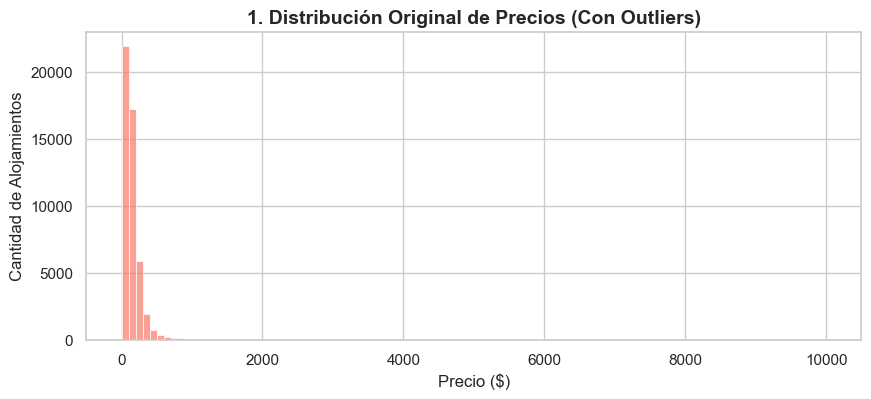

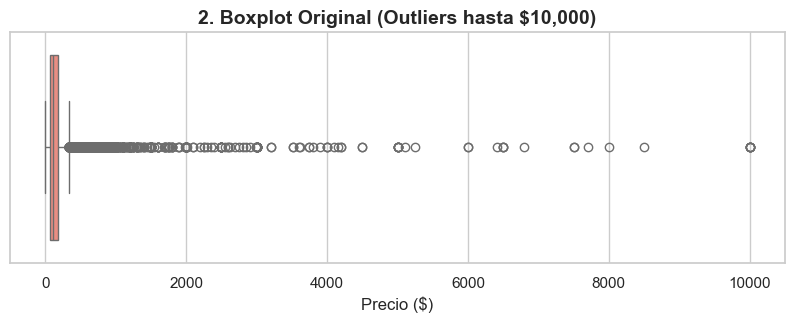

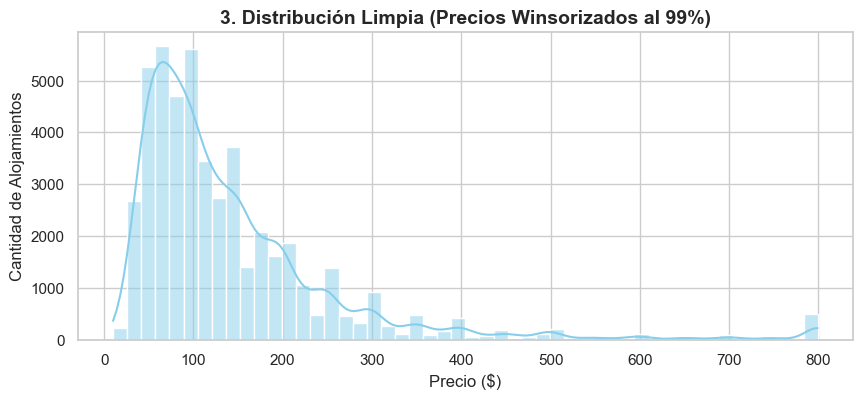

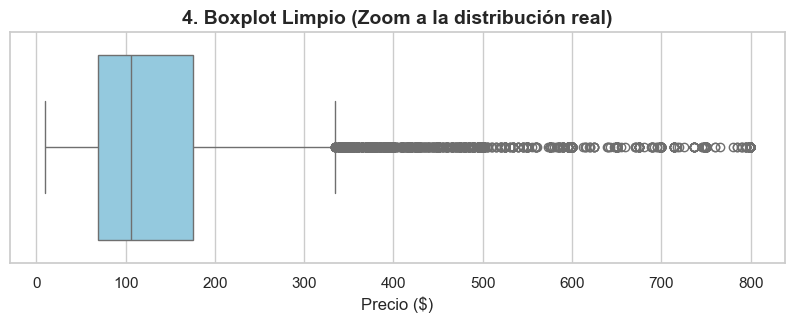

In [48]:


sns.set_theme(style="whitegrid")

# HISTOGRAMA ORIGINAL 
plt.figure(figsize=(10, 4))
sns.histplot(abnb_orig['price'], bins=100, color='salmon', kde=False)
plt.title('1. Distribución Original de Precios (Con Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Precio ($)')
plt.ylabel('Cantidad de Alojamientos')
plt.show()

# BOXPLOT ORIGINAL
plt.figure(figsize=(10, 3))
sns.boxplot(data=abnb_orig, x='price', color='salmon')
plt.title('2. Boxplot Original (Outliers hasta $10,000)', fontsize=14, fontweight='bold')
plt.xlabel('Precio ($)')
plt.show()

# HISTOGRAMA LIMPIO (WINSORIZADO)
plt.figure(figsize=(10, 4))
sns.histplot(abnb_clean['price'], bins=50, color='skyblue', kde=True)
plt.title('3. Distribución Limpia (Precios Winsorizados al 99%)', fontsize=14, fontweight='bold')
plt.xlabel('Precio ($)')
plt.ylabel('Cantidad de Alojamientos')
plt.show()

# BOXPLOT LIMPIO (WINSORIZADO) 
plt.figure(figsize=(10, 3))
sns.boxplot(data=abnb_clean, x='price', color='skyblue')
plt.title('4. Boxplot Limpio (Zoom a la distribución real)', fontsize=14, fontweight='bold')
plt.xlabel('Precio ($)')
plt.show()

Mapa de correlaciones

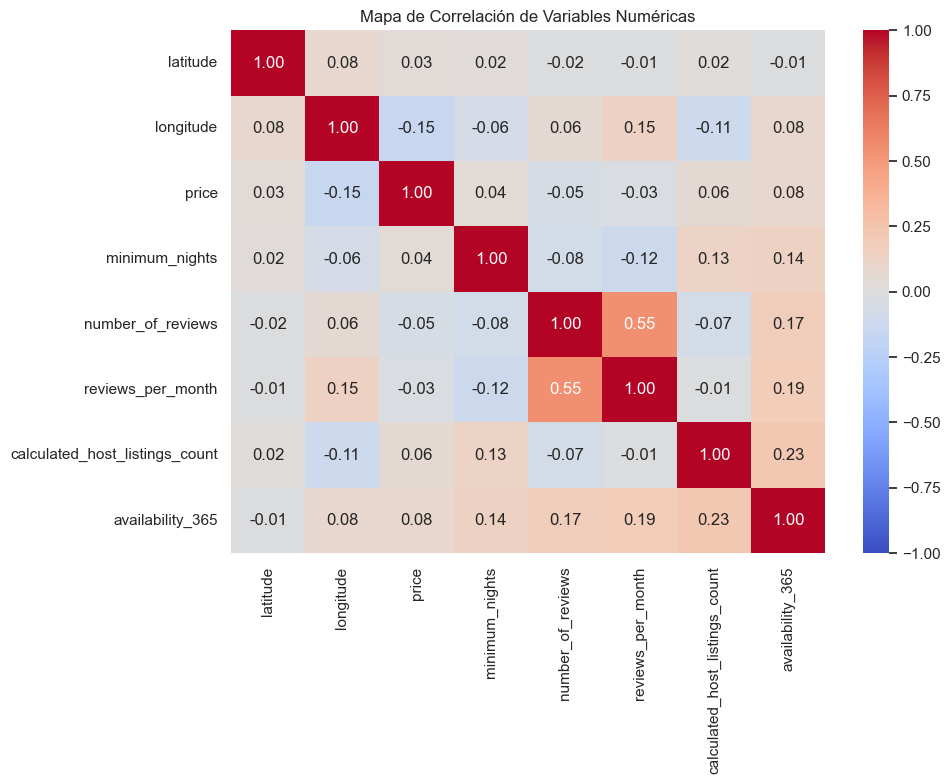

In [44]:
plt.figure(figsize=(10, 8))
# Filtramos solo las columnas numéricas
numeric_cols = abnb_orig.select_dtypes(include=[np.number])
# Eliminamos 'id' y 'host_id' porque no tiene sentido buscarles correlación matemática
numeric_cols = numeric_cols.drop(columns=['id', 'host_id'])

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.tight_layout()
plt.savefig('correlation.png')
plt.show()

Tratamiento de datos 

A pesar de que los precios cero son una muestra poco representativa voy a manipularlos con fines didácticos 

In [31]:
abnb_orig['price'] = abnb_orig['price'].replace(0, np.nan)



Calculamos los promedios agrupados usando .transform('mean') para generar una columna "virtual" con los promedios correspondientes a cada fila según su barrio y tipo de habitación


In [32]:
promedios_agrupados = abnb_orig.groupby(['neighbourhood', 'room_type'])['price'].transform('mean')

He rellenado los valores nulos con los promedios calculados 

In [33]:
abnb_orig['price'] = abnb_orig['price'].fillna(promedios_agrupados)
abnb_orig['price'] = abnb_orig['price'].round(2)
print(f"Precios nulos restantes: {abnb_orig['price'].isna().sum()}")

Precios nulos restantes: 0


Para los valores nulos de "reviews_per_month" con cero y los nulos en 'last_review' con un texto indicativo

In [34]:

abnb_orig['reviews_per_month'] = abnb_orig['reviews_per_month'].fillna(0)

abnb_orig['last_review'] = abnb_orig['last_review'].fillna('Sin reseñas')

print("Valores nulos restantes por columna:")
print(abnb_orig.isna().sum())

Valores nulos restantes por columna:
id                                 0
name                              16
host_id                            0
host_name                         21
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64


Los valores de "name" y "host_name" seran rellenados con textos para eliminar todos los valores nulos 

In [35]:

abnb_orig['name'] = abnb_orig['name'].fillna('Sin nombre')
abnb_orig['host_name'] = abnb_orig['host_name'].fillna('Desconocido')
print(abnb_orig.isna().sum())

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


Este gráfico final no es mío lo he copiado de una reporte y lo he hecho con copilot para poder incluir las etiquetas 

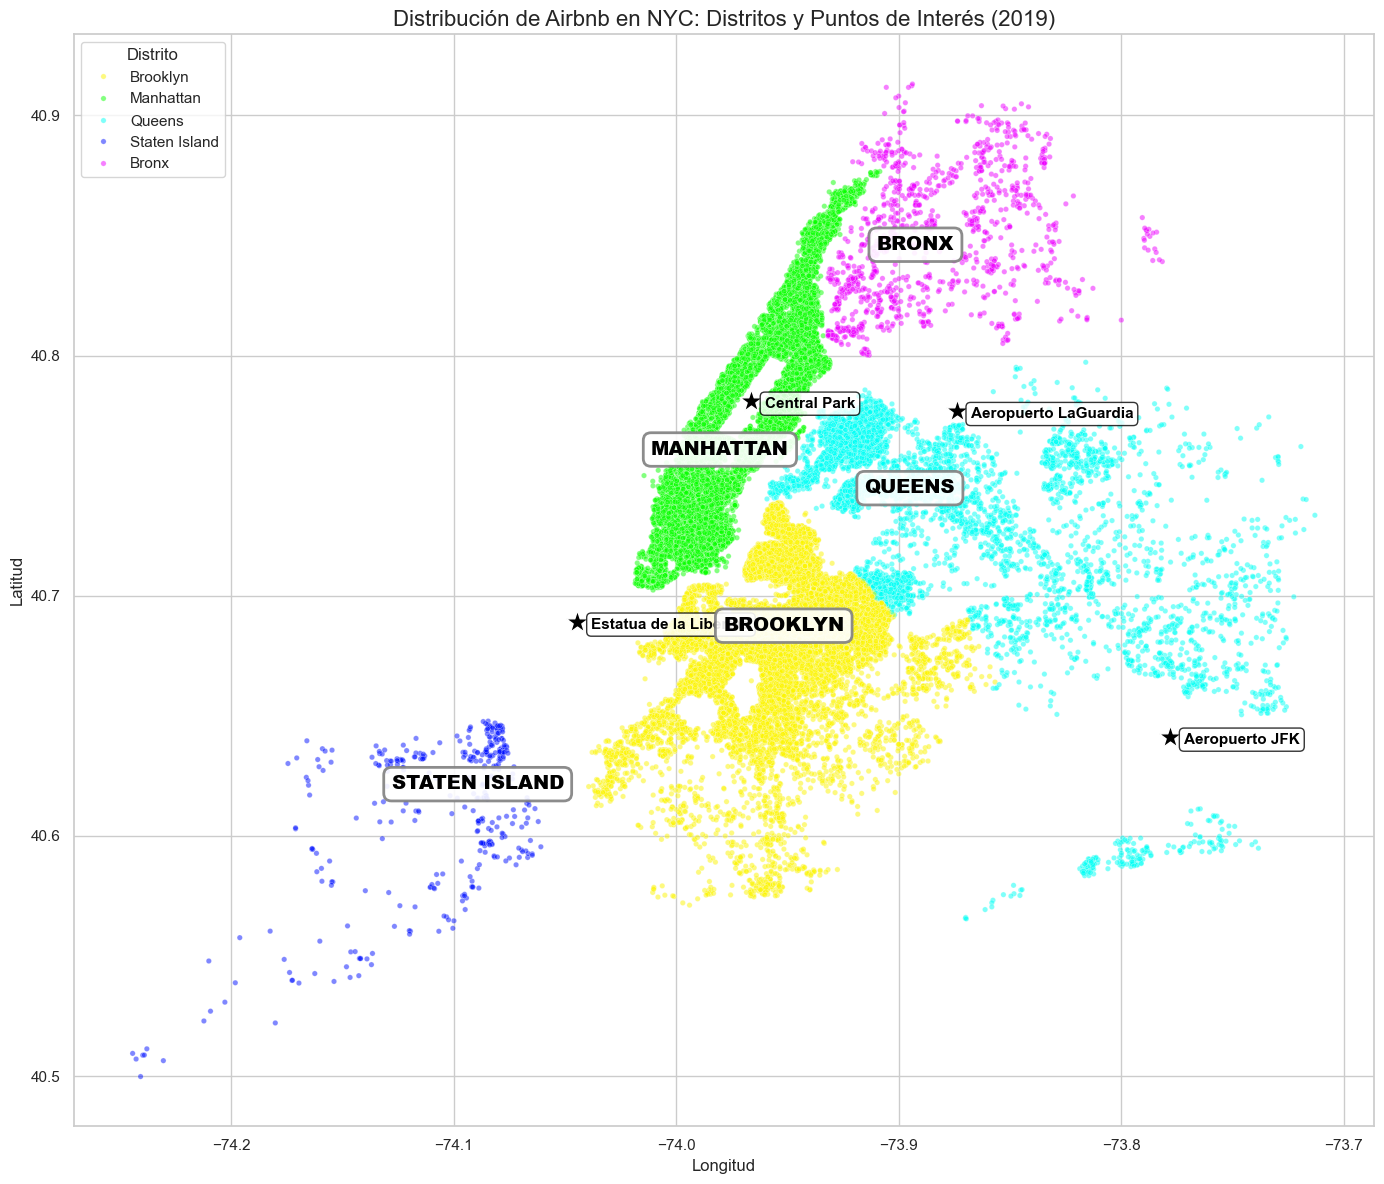

In [36]:



sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 12)) 


sns.scatterplot(x='longitude', y='latitude', hue='neighbourhood_group', 
                data=abnb_orig, palette='hsv', s=15, alpha=0.5)


landmarks = {
    'Aeropuerto JFK': (-73.7781, 40.6413),
    'Aeropuerto LaGuardia': (-73.8740, 40.7769),
    'Central Park': (-73.9665, 40.7812),
    'Estatua de la Libertad': (-74.0445, 40.6892)
}


for name, (lon, lat) in landmarks.items():
    plt.scatter(lon, lat, color='black', marker='*', s=300, edgecolor='white', zorder=5)
    plt.annotate(name, (lon, lat), textcoords="offset points", xytext=(10,-5), 
                 ha='left', fontsize=11, fontweight='bold', color='black',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1, alpha=0.8),
                 zorder=6)


borough_centers = abnb_orig.groupby('neighbourhood_group')[['longitude', 'latitude']].median()


for borough, row in borough_centers.iterrows():
    plt.annotate(borough.upper(), (row['longitude'], row['latitude']), 
                 ha='center', va='center', fontsize=14, fontweight='heavy', color='black',
                 bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", lw=2, alpha=0.9),
                 zorder=7) 
plt.title('Distribución de Airbnb en NYC: Distritos y Puntos de Interés (2019)', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Distrito', loc='upper left')
plt.tight_layout()


plt.savefig('map_nyc_landmarks_boroughs.png')
plt.show()

Conclusiones 


Los datos de 2019 desmontan el mito fundacional de Airbnb (particulares alquilando una habitación libre). El mercado neoyorquino estaba fuertemente dominado por operadores comerciales. Empresas como Sonder (NYC) y Blueground controlaban cientos de anuncios simultáneamente. Además, la altísima tasa de anuncios inactivos o "fantasma" (un 35.8% de las propiedades tenían 0 días de disponibilidad anual y el 20% jamás recibió una reseña) sugiere un mercado saturado de cuentas corporativas, especuladores inactivos o anfitriones bloqueados por las normativas de la ciudad.


La distribución de room_type es categórica: el modelo de "Habitación compartida" (Shared room) era un fracaso comercial en Nueva York (menos del 2.5% del mercado). Los huéspedes exigían privacidad absoluta, dividiendo sus preferencias casi equitativamente entre "Apartamentos/Casas enteras" (para familias o grupos con mayor presupuesto) y "Habitaciones privadas" (el estándar para parejas y viajeros en solitario).


El precio promedio real de una noche en NYC no eran los 152$ que dicta la media matemática, sino los 106$ de la mediana. El mercado estaba inflado artificialmente por una minoría de alojamientos de ultralujo en Manhattan (con tarifas de hasta 10.000$ la noche) que distorsionaban la percepción general. Para el turista promedio, Nueva York ofrecía una inmensa oferta en el rango de los 60$ a 150$.

Estadística final para las conclusiones 

In [37]:


total_listings = len(abnb_orig)
mean_price = abnb_orig['price'].mean()
median_price = abnb_orig['price'].median()

rango_turista = abnb_orig[(abnb_orig['price'] >= 60) & (abnb_orig['price'] <= 150)]
cantidad_rango = len(rango_turista)
porcentaje_rango = (cantidad_rango / total_listings) * 100


lujo_500 = len(abnb_orig[abnb_orig['price'] > 500])
porcentaje_500 = (lujo_500 / total_listings) * 100

lujo_1000 = len(abnb_orig[abnb_orig['price'] > 1000])
porcentaje_1000 = (lujo_1000 / total_listings) * 100


p25 = abnb_orig['price'].quantile(0.25)
p75 = abnb_orig['price'].quantile(0.75)


print("--- ANÁLISIS DEL PRECIO REAL EN NYC ---")
print(f"Total de anuncios evaluados: {total_listings}")
print(f"Media matemática (engañosa): {mean_price:.2f}$")
print(f"Mediana (el precio del 50% exacto): {median_price:.2f}$")
print(f"El 50% de los anuncios están entre {p25}$ (Cuartil 25) y {p75}$ (Cuartil 75)\n")

print("DISTRIBUCIÓN DEL MERCADO")
print(f"Anuncios accesibles (entre 60$ y 150$): {cantidad_rango} ({porcentaje_rango:.2f}% de la oferta total)")
print(f"Anuncios de lujo (> 500$): {lujo_500} ({porcentaje_500:.2f}% de la oferta total)")
print(f"Anuncios de ultralujo (> 1000$): {lujo_1000} ({porcentaje_1000:.2f}% de la oferta total)")

--- ANÁLISIS DEL PRECIO REAL EN NYC ---
Total de anuncios evaluados: 48895
Media matemática (engañosa): 152.74$
Mediana (el precio del 50% exacto): 106.00$
El 50% de los anuncios están entre 69.0$ (Cuartil 25) y 175.0$ (Cuartil 75)

DISTRIBUCIÓN DEL MERCADO
Anuncios accesibles (entre 60$ y 150$): 25359 (51.86% de la oferta total)
Anuncios de lujo (> 500$): 1044 (2.14% de la oferta total)
Anuncios de ultralujo (> 1000$): 239 (0.49% de la oferta total)



A pesar de la percepción tradicional, los barrios con mayor densidad de alojamientos de toda la ciudad no se encuentran en Manhattan, sino en Brooklyn, liderados por Williamsburg y Bedford-Stuyvesant. Esta concentración responde a la búsqueda de un equilibrio óptimo entre precio y experiencia por parte de los viajeros. Brooklyn ofrece tarifas considerablemente más accesibles, manteniendo al mismo tiempo una rápida conexión en metro con el centro neurálgico. El mercado en esta zona está dominado por la oferta de habitaciones privadas, consolidándose como el destino preferido para un turismo joven o de presupuesto medio que prioriza un ambiente auténtico y cultural sin asumir el sobrecoste de la isla principal.

Manhattan concentra de forma exclusiva los precios más altos del mercado y la mayor proporción de apartamentos enteros. Esta dinámica refleja un perfil de huésped dispuesto a asumir tarifas premium a cambio de una ubicación privilegiada junto a los principales puntos de interés (Times Square, Central Park) y la exclusividad de no compartir el espacio. La barrera de entrada es tan alta que los precios más bajos de Manhattan equivalen a los precios medios-altos del resto de la ciudad. Como excepción interna, Harlem funciona como una válvula de escape financiera, permitiendo el alojamiento en la isla a precios ligeramente más competitivos gracias a su ubicación más al norte.


Estos tres distritos representan de manera conjunta menos del 15% del mercado total. Su escasa cuota se debe a la penalización directa que sufren por su lejanía de los principales focos turísticos. Sin embargo, logran sostener pequeños núcleos de actividad (como Astoria o Jamaica en Queens) gracias a un modelo de negocio de nicho: la extrema proximidad a los aeropuertos JFK y LaGuardia. Estos alojamientos sobreviven al captar un público puramente funcional, compuesto por viajeros en escala, tripulaciones de vuelo o trabajadores temporales cuya única prioridad es encontrar la opción más económica de toda la base de datos.

Para este proyecto he decidido conservar todas las variables originales. Al no contar con un objetivo de negocio predefinido, mi enfoque ha sido realizar una exploración amplia y extraer conclusiones versátiles que puedan servir como base para cualquier análisis futuro